# Training loss: 1024 vs 8196 MLP across probe layers

Ten networks: layers {1, 8, 16, 24, 32} x widths {1024, 8196}, same aligned 50k-prompt
store, same 2-layer SiLU MLP, same cosine DDPM schedule.

- **Red family = 1024-wide**, **blue family = 8196-wide**
- Within each family, deeper layer -> darker shade (layer 1 lightest, layer 32 darkest)
- Loss is the epsilon-MSE training loss (`split == "train"` records in `train.jsonl`)
- Logs taken after the last `lr_retry` event when a run was restarted at half LR

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

ROOT = Path.cwd() if (Path.cwd() / "runs").exists() else Path.cwd().parent
LAYERS = [1, 8, 16, 24, 32]
RUNS = {
    "1024": ROOT / "runs/mlp1024/logs",
    "8196": ROOT / "logs",
}

def load_train_loss(log_dir: Path, layer: int):
    recs = [json.loads(x) for x in (log_dir / f"layer_{layer:02d}" / "train.jsonl").read_text().splitlines()]
    last_retry = max((i for i, r in enumerate(recs) if r.get("event") == "lr_retry"), default=-1)
    tr = [r for r in recs[last_retry + 1:] if r.get("split") == "train"]
    steps = np.array([r["step"] for r in tr])
    loss = np.array([r["loss"] for r in tr])
    order = np.argsort(steps)
    return steps[order], loss[order]

curves = {(w, l): load_train_loss(d, l) for w, d in RUNS.items() for l in LAYERS}
for (w, l), (s, y) in sorted(curves.items()):
    print(f"{w} L{l:<2} {len(s):>4} pts  step<= {s.max():>6}  loss [{y.min():.3f}, {y.max():.3f}]")

1024 L1  1000 pts  step<=  50000  loss [0.336, 0.570]
1024 L8  1000 pts  step<=  50000  loss [0.356, 0.536]
1024 L16 1000 pts  step<=  50000  loss [0.337, 0.533]
1024 L24 1000 pts  step<=  50000  loss [0.364, 0.534]
1024 L32 1000 pts  step<=  50000  loss [0.332, 0.526]
8196 L1  1000 pts  step<=  50000  loss [0.351, 0.562]
8196 L8  1000 pts  step<=  50000  loss [0.343, 0.521]
8196 L16 1000 pts  step<=  50000  loss [0.342, 0.513]
8196 L24 1000 pts  step<=  50000  loss [0.343, 0.520]
8196 L32 1000 pts  step<=  50000  loss [0.336, 0.526]


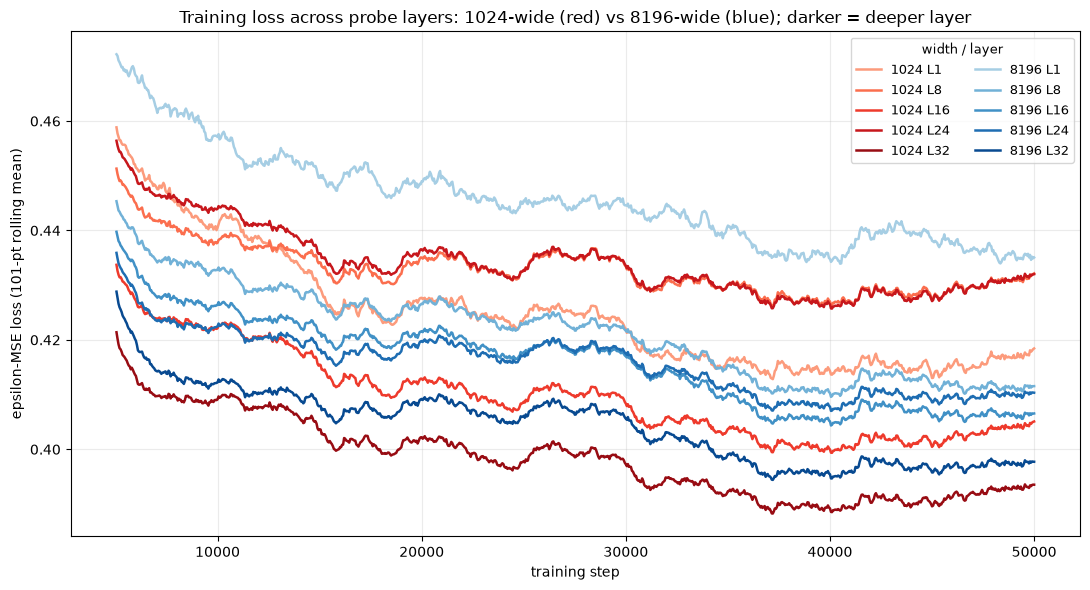

In [2]:
fig, ax = plt.subplots(figsize=(11, 6))

shades = np.linspace(0.35, 0.9, len(LAYERS))
cmap = {"1024": plt.cm.Reds, "8196": plt.cm.Blues}

window = 101

for width in ("1024", "8196"):
    for shade, layer in zip(shades, LAYERS):
        steps, loss = curves[(width, layer)]

        kernel = np.ones(window) / window
        smooth = np.convolve(loss, kernel, mode="valid")

        ax.plot(
            steps[window - 1:],
            smooth,
            color=cmap[width](shade),
            lw=1.8,
            label=f"{width} L{layer}",
        )

ax.set_xlabel("training step")
ax.set_ylabel(f"epsilon-MSE loss ({window}-pt rolling mean)")
ax.set_title(
    "Training loss across probe layers: "
    "1024-wide (red) vs 8196-wide (blue); darker = deeper layer"
)
ax.legend(ncol=2, fontsize=9, title="width / layer", title_fontsize=9)
ax.grid(alpha=0.25)

fig.tight_layout()
fig.savefig(ROOT / "notebooks" / "training_loss.png", dpi=160)
plt.show()

Notes: the 1024 runs bottom out earlier (val-selected best checkpoints sit at 4k-17k steps)
while the 8196 runs keep improving to 37k-40.5k. Deeper-layer curves sit lower for 8196
(more capacity), except layer 1 where the two widths are essentially tied.

## Validation and test loss

Left: validation epsilon-MSE per eval step (every 500 steps, from `train.jsonl`).
Right: test epsilon-MSE evaluated once at each network's best checkpoint
(`runs/mlp1024/loss_summary.json`, `runs/mlp8196/loss_summary.json`).
Same color language: red = 1024-wide, blue = 8196-wide, darker = deeper layer.

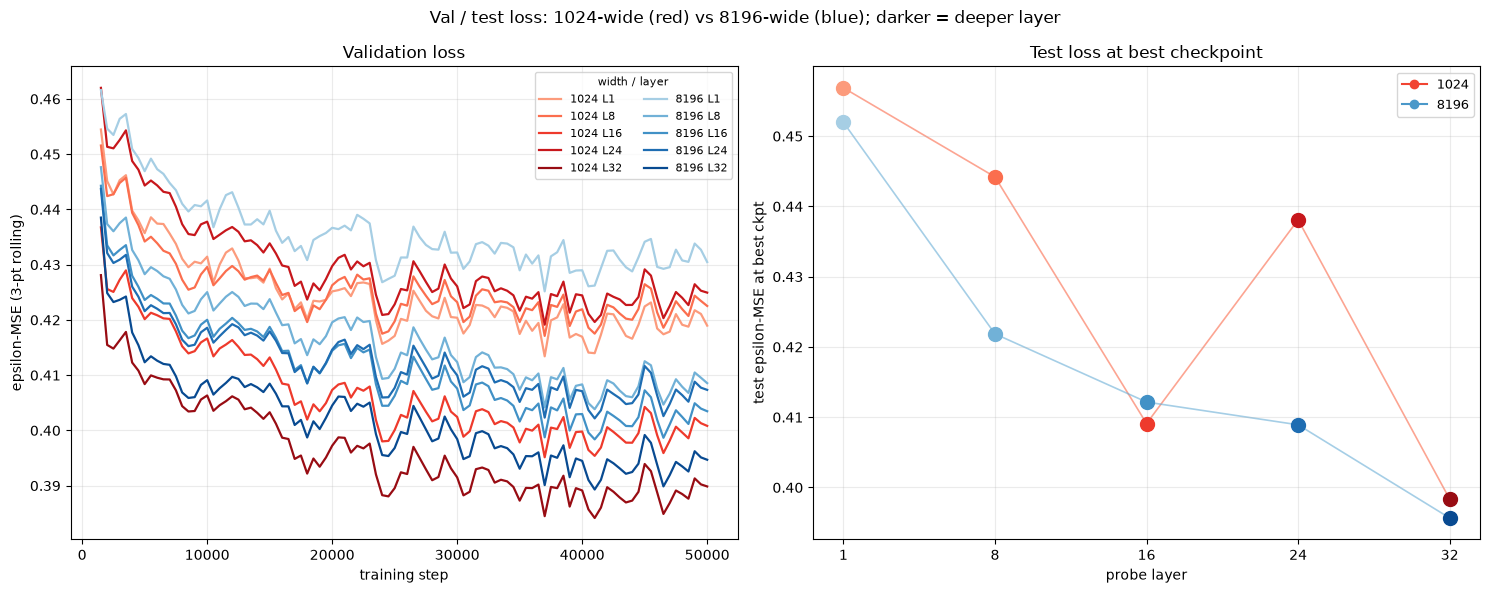

1024 L1  best@ 17000  test=0.4569
1024 L8  best@  4000  test=0.4442
1024 L16 best@ 17000  test=0.4091
1024 L24 best@ 10500  test=0.4381
1024 L32 best@ 17000  test=0.3983
8196 L1  best@ 37000  test=0.4520
8196 L8  best@ 40500  test=0.4219
8196 L16 best@ 40500  test=0.4122
8196 L24 best@ 40500  test=0.4089
8196 L32 best@ 40500  test=0.3957


In [3]:
fig, (ax_v, ax_t) = plt.subplots(1, 2, figsize=(15, 6))
shades = np.linspace(0.35, 0.9, len(LAYERS))

def load_val_loss(log_dir, layer):
    recs = [json.loads(x) for x in (log_dir / f"layer_{layer:02d}" / "train.jsonl").read_text().splitlines()]
    last_retry = max((i for i, r in enumerate(recs) if r.get("event") == "lr_retry"), default=-1)
    va = [r for r in recs[last_retry + 1:] if r.get("split") == "val"]
    steps = np.array([r["step"] for r in va])
    loss = np.array([r["loss"] for r in va])
    order = np.argsort(steps)
    return steps[order], loss[order]

for width in ("1024", "8196"):
    for shade, layer in zip(shades, LAYERS):
        s, y = load_val_loss(RUNS[width], layer)
        sm = np.convolve(y, np.ones(3) / 3, mode="valid")
        ax_v.plot(s[2:], sm, color=cmap[width](shade), lw=1.6, label=f"{width} L{layer}")
ax_v.set_xlabel("training step")
ax_v.set_ylabel("epsilon-MSE (3-pt rolling)")
ax_v.set_title("Validation loss")
ax_v.legend(ncol=2, fontsize=8, title="width / layer", title_fontsize=8)
ax_v.grid(alpha=0.25)

summary = {}
for tag, width in (("mlp1024", "1024"), ("mlp8196", "8196")):
    d = json.loads((ROOT / "runs" / tag / "loss_summary.json").read_text())
    summary[width] = {int(k): v for k, v in d["layers"].items()}
x = np.arange(len(LAYERS))
for width in ("1024", "8196"):
    ys = [summary[width][l]["test_loss"] for l in LAYERS]
    ax_t.plot(x, ys, "-", color=cmap[width](0.5), lw=1.2, alpha=0.6, zorder=1)
for i, (shade, layer) in enumerate(zip(shades, LAYERS)):
    for width in ("1024", "8196"):
        y = summary[width][layer]["test_loss"]
        ax_t.plot(x[i], y, "o", color=cmap[width](shade), ms=10, zorder=2)
ax_t.set_xticks(x, [str(l) for l in LAYERS])
ax_t.set_xlabel("probe layer")
ax_t.set_ylabel("test epsilon-MSE at best ckpt")
ax_t.set_title("Test loss at best checkpoint")
ax_t.grid(alpha=0.25)
ax_t.legend(handles=[
    plt.Line2D([], [], color=cmap["1024"](0.6), marker="o", ls="-", label="1024"),
    plt.Line2D([], [], color=cmap["8196"](0.6), marker="o", ls="-", label="8196"),
], fontsize=9)

fig.suptitle("Val / test loss: 1024-wide (red) vs 8196-wide (blue); darker = deeper layer")
fig.tight_layout()
fig.savefig(ROOT / "notebooks" / "val_test_loss.png", dpi=160)
plt.show()

for width in ("1024", "8196"):
    for layer in LAYERS:
        r = summary[width][layer]
        print(f'{width} L{layer:<2} best@{r["best_step"]:>6}  test={r["test_loss"]:.4f}')